In [2]:
# ================================================================
# BAGIAN 1 — SETUP & KONFIGURASI
# ================================================================

# 1 Import Libraries
import os
import warnings
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, CSVLogger
)
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings('ignore')

# 2 Reproducibility
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

# 3 Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# ================================================================
# BAGIAN 2 — KONFIGURASI GLOBAL
# ================================================================

# Path dataset
BASE_PATH  = "/content/drive/MyDrive/Cat_Breed"
TRAIN_PATH = os.path.join(BASE_PATH, "train")
VAL_PATH   = os.path.join(BASE_PATH, "val")
TEST_PATH  = os.path.join(BASE_PATH, "test")
SAVE_PATH  = os.path.join(BASE_PATH, "saved_model")
os.makedirs(SAVE_PATH, exist_ok=True)

# Hyperparameter
IMG_SIZE       = (224, 224)
BATCH_SIZE     = 16
NUM_CLASSES    = 5
EPOCHS_STAGE1  = 50
EPOCHS_STAGE2  = 30
LR_STAGE1 = 5e-4
LR_STAGE2 = 5e-5
LABEL_SMOOTHING = 0.1
LAST_CONV_LAYER = "block5_conv3"  # Layer target Grad-CAM

print(f"\n  Dataset    : {BASE_PATH}")
print(f"  Output     : {SAVE_PATH}")
print(f"  Batch size : {BATCH_SIZE}")
print(f"  Label Smoothing : {LABEL_SMOOTHING}")


  Dataset    : /content/drive/MyDrive/Cat_Breed
  Output     : /content/drive/MyDrive/Cat_Breed/saved_model
  Batch size : 16
  Label Smoothing : 0.1


In [4]:
# ================================================================
# BAGIAN 3 — DATA LOADING & AUGMENTASI
# ================================================================

# Augmentasi HANYA untuk training — val/test cukup rescale
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=[0.85, 1.15],
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=SEED
)

val_generator = val_test_datagen.flow_from_directory(
    VAL_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    TEST_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Ambil class_names dari generator (urutan sesuai folder alphabetical)
CLASS_NAMES = list(train_generator.class_indices.keys())

print(f"\n  Total training : {train_generator.samples}")
print(f"  Total validasi : {val_generator.samples}")
print(f"  Total test     : {test_generator.samples}")
print(f"  Kelas          : {train_generator.class_indices}")

Found 1752 images belonging to 5 classes.
Found 375 images belonging to 5 classes.
Found 375 images belonging to 5 classes.

  Total training : 1752
  Total validasi : 375
  Total test     : 375
  Kelas          : {'Bombay': 0, 'Maine_Coon': 1, 'Scottish_Fold': 2, 'Siamese': 3, 'Sphynx': 4}


In [5]:
# ================================================================
# BAGIAN 4 — CLASS WEIGHT
# ================================================================
# Menyeimbangkan pengaruh kelas yang jumlah datanya tidak merata
# agar model tidak bias ke kelas mayoritas.

class_weight_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weight_dict = dict(enumerate(class_weight_array))
print(f"\n  Class Weights : {class_weight_dict}")


  Class Weights : {0: np.float64(1.0011428571428571), 1: np.float64(0.9954545454545455), 2: np.float64(1.0011428571428571), 3: np.float64(1.0011428571428571), 4: np.float64(1.0011428571428571)}


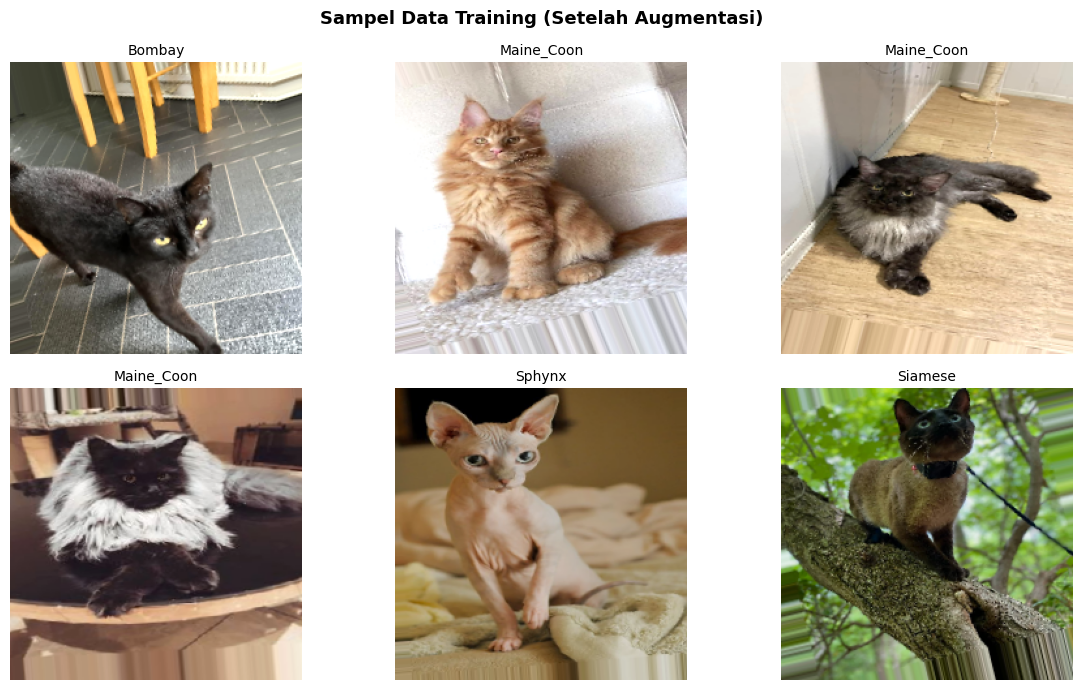

In [6]:
# ================================================================
# BAGIAN 5 — VISUALISASI SAMPEL DATA
# ================================================================

def visualize_samples(generator, class_names, n=6):
    """Menampilkan n sampel gambar beserta label kelasnya."""
    images, labels = next(generator)
    fig, axes = plt.subplots(2, 3, figsize=(12, 7))
    fig.suptitle("Sampel Data Training (Setelah Augmentasi)",
                 fontsize=13, fontweight='bold')
    for i, ax in enumerate(axes.flat):
        if i < n and i < len(images):
            ax.imshow(images[i])
            ax.set_title(class_names[np.argmax(labels[i])], fontsize=10)
        ax.axis('off')
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_PATH, 'sample_data.png'), dpi=120, bbox_inches='tight')
    plt.show()

visualize_samples(train_generator, CLASS_NAMES)

In [7]:
# ================================================================
# BAGIAN 6 — ARSITEKTUR MODEL
# ================================================================

def build_model(num_classes: int) -> tuple:
    """
    Membangun model VGG16 + custom classification head.

    Arsitektur head:
      GAP → BatchNorm → Dense(256, L2) → Dropout(0.5)
           → Dense(128, L2) → Dropout(0.3) → Softmax(num_classes)

    Returns:
        model      : Model lengkap (siap compile)
        base_model : Referensi ke VGG16 base (untuk fine-tuning)
    """
    base_model = VGG16(
        weights='imagenet',
        include_top=False,
        input_shape=(224, 224, 3)
    )

    # Stage 1: semua layer VGG16 dibekukan
    for layer in base_model.layers:
        layer.trainable = False

    x = base_model.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(128, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.3)(x)
    output = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs=base_model.input, outputs=output)
    return model, base_model


model, base_model = build_model(NUM_CLASSES)

loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR_STAGE1),
    loss=loss_fn,
    metrics=['accuracy']
)

model.summary()
trainable_params = sum([tf.size(w).numpy() for w in model.trainable_weights])
print(f"\n  Total parameter     : {model.count_params():,}")
print(f"  Parameter trainable : {trainable_params:,}")

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,89

 Total params: 14,881,605 (56.77 MB)

 Trainable params: 165,893 (648.02 KB)

 Non-trainable params: 14,715,712 (56.14 MB)


  Total parameter     : 14,881,605
  Parameter trainable : 165,893


In [8]:
# ================================================================
# BAGIAN 7 — BUILDER CALLBACKS (Fungsi, bukan duplikasi)
# ================================================================
# Dibuat sebagai fungsi agar tidak ada duplikasi kode antara

def build_callbacks(stage: int, save_path: str) -> list:
    """
    Membangun daftar callback untuk satu stage training.

    Callback yang digunakan:
    - EarlyStopping    : Hentikan training jika val_loss tidak membaik
    - ReduceLROnPlateau: Turunkan LR saat training stagnan
    - ModelCheckpoint  : Simpan bobot terbaik otomatis
    - CSVLogger        : [BARU] Catat semua metrik per epoch ke file CSV
    """
    return [
        EarlyStopping(
            monitor='val_loss',
            patience=7,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            patience=3,
            factor=0.5,
            min_lr=1e-8,
            verbose=1
        ),
        ModelCheckpoint(
            filepath=os.path.join(save_path, f'best_stage{stage}.h5'),
            monitor='val_accuracy',
            save_best_only=True,
            mode='max',
            verbose=1
        ),

        CSVLogger(
            filename=os.path.join(save_path, f'training_log_stage{stage}.csv'),
            append=False
        ),
    ]

In [9]:
# ================================================================
# BAGIAN 8 — TRAINING STAGE 1 (Head Only)
# ================================================================

print("\n" + "=" * 60)
print("  STAGE 1 — Training Classification Head")
print("  (Semua layer VGG16 dibekukan)")
print("=" * 60)

history_stage1 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS_STAGE1,
    callbacks=build_callbacks(stage=1, save_path=SAVE_PATH),
    class_weight=class_weight_dict,
    verbose=1
)


  STAGE 1 — Training Classification Head
  (Semua layer VGG16 dibekukan)
Epoch 1/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.3587 - loss: 1.6716
Epoch 1: val_accuracy improved from None to 0.58400, saving model to /content/drive/MyDrive/Cat_Breed/saved_model/best_stage1.h5



Epoch 1: finished saving model to /content/drive/MyDrive/Cat_Breed/saved_model/best_stage1.h5
110/110 ━━━━━━━━━━━━━━━━━━━━ 1365s 12s/step - accuracy: 0.4783 - loss: 1.4603 - val_accuracy: 0.5840 - val_loss: 1.4174 - learning_rate: 5.0000e-04
Epoch 2/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 479ms/step - accuracy: 0.6793 - loss: 1.0918
Epoch 2: val_accuracy improved from 0.58400 to 0.82933, saving model to /content/drive/MyDrive/Cat_Breed/saved_model/best_stage1.h5



Epoch 2: finished saving model to /content/drive/MyDrive/Cat_Breed/saved_model/best_stage1.h5
110/110 ━━━━━━━━━━━━━━━━━━━━ 61s 552ms/step - accuracy: 0.6826 - loss: 1.0857 - val_accuracy: 0.8293 - val_loss: 1.1529 - learning_rate: 5.0000e-04
Epoch 3/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 481ms/step - accuracy: 0.7260 - loss: 1.0260
Epoch 3: val_accuracy improved from 0.82933 to 0.86133, saving model to /content/drive/MyDrive/Cat_Breed/saved_model/best_stage1.h5



Epoch 3: finished saving model to /content/drive/MyDrive/Cat_Breed/saved_model/best_stage1.h5
110/110 ━━━━━━━━━━━━━━━━━━━━ 66s 595ms/step - accuracy: 0.7432 - loss: 0.9843 - val_accuracy: 0.8613 - val_loss: 0.9197 - learning_rate: 5.0000e-04
Epoch 4/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 482ms/step - accuracy: 0.7707 - loss: 0.9300
Epoch 4: val_accuracy improved from 0.86133 to 0.88267, saving model to /content/drive/MyDrive/Cat_Breed/saved_model/best_stage1.h5



Epoch 4: finished saving model to /content/drive/MyDrive/Cat_Breed/saved_model/best_stage1.h5
110/110 ━━━━━━━━━━━━━━━━━━━━ 61s 555ms/step - accuracy: 0.7620 - loss: 0.9562 - val_accuracy: 0.8827 - val_loss: 0.8024 - learning_rate: 5.0000e-04
Epoch 5/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 478ms/step - accuracy: 0.7764 - loss: 0.9003
Epoch 5: val_accuracy did not improve from 0.88267
110/110 ━━━━━━━━━━━━━━━━━━━━ 59s 534ms/step - accuracy: 0.7757 - loss: 0.9050 - val_accuracy: 0.8773 - val_loss: 0.7541 - learning_rate: 5.0000e-04
Epoch 6/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 473ms/step - accuracy: 0.8077 - loss: 0.8972
Epoch 6: val_accuracy improved from 0.88267 to 0.90400, saving model to /content/drive/MyDrive/Cat_Breed/saved_model/best_stage1.h5



Epoch 6: finished saving model to /content/drive/MyDrive/Cat_Breed/saved_model/best_stage1.h5
110/110 ━━━━━━━━━━━━━━━━━━━━ 65s 587ms/step - accuracy: 0.8145 - loss: 0.8736 - val_accuracy: 0.9040 - val_loss: 0.7193 - learning_rate: 5.0000e-04
Epoch 7/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 485ms/step - accuracy: 0.8183 - loss: 0.8582
Epoch 7: val_accuracy improved from 0.90400 to 0.90933, saving model to /content/drive/MyDrive/Cat_Breed/saved_model/best_stage1.h5



Epoch 7: finished saving model to /content/drive/MyDrive/Cat_Breed/saved_model/best_stage1.h5
110/110 ━━━━━━━━━━━━━━━━━━━━ 62s 559ms/step - accuracy: 0.8265 - loss: 0.8439 - val_accuracy: 0.9093 - val_loss: 0.7102 - learning_rate: 5.0000e-04
Epoch 8/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 481ms/step - accuracy: 0.8221 - loss: 0.8462
Epoch 8: val_accuracy did not improve from 0.90933
110/110 ━━━━━━━━━━━━━━━━━━━━ 60s 541ms/step - accuracy: 0.8213 - loss: 0.8549 - val_accuracy: 0.9067 - val_loss: 0.7211 - learning_rate: 5.0000e-04
Epoch 9/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 472ms/step - accuracy: 0.8244 - loss: 0.8459
Epoch 9: val_accuracy improved from 0.90933 to 0.92000, saving model to /content/drive/MyDrive/Cat_Breed/saved_model/best_stage1.h5



Epoch 9: finished saving model to /content/drive/MyDrive/Cat_Breed/saved_model/best_stage1.h5
110/110 ━━━━━━━━━━━━━━━━━━━━ 61s 550ms/step - accuracy: 0.8293 - loss: 0.8416 - val_accuracy: 0.9200 - val_loss: 0.7079 - learning_rate: 5.0000e-04
Epoch 10/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 480ms/step - accuracy: 0.8411 - loss: 0.7929
Epoch 10: val_accuracy did not improve from 0.92000
110/110 ━━━━━━━━━━━━━━━━━━━━ 59s 532ms/step - accuracy: 0.8345 - loss: 0.8003 - val_accuracy: 0.9120 - val_loss: 0.7028 - learning_rate: 5.0000e-04
Epoch 11/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 483ms/step - accuracy: 0.8529 - loss: 0.7793
Epoch 11: val_accuracy did not improve from 0.92000
110/110 ━━━━━━━━━━━━━━━━━━━━ 59s 534ms/step - accuracy: 0.8545 - loss: 0.7825 - val_accuracy: 0.9040 - val_loss: 0.7174 - learning_rate: 5.0000e-04
Epoch 12/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 478ms/step - accuracy: 0.8728 - loss: 0.7631
Epoch 12: val_accuracy did not improve from 0.92000
110/110 ━━━━━━━━━━━━━━━━━━━━ 58s 530ms


Epoch 19: finished saving model to /content/drive/MyDrive/Cat_Breed/saved_model/best_stage1.h5
110/110 ━━━━━━━━━━━━━━━━━━━━ 60s 541ms/step - accuracy: 0.8955 - loss: 0.7274 - val_accuracy: 0.9307 - val_loss: 0.6798 - learning_rate: 5.0000e-04
Epoch 20/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 476ms/step - accuracy: 0.8908 - loss: 0.7223
Epoch 20: val_accuracy did not improve from 0.93067
110/110 ━━━━━━━━━━━━━━━━━━━━ 58s 527ms/step - accuracy: 0.8921 - loss: 0.7201 - val_accuracy: 0.9200 - val_loss: 0.6929 - learning_rate: 5.0000e-04
Epoch 21/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 478ms/step - accuracy: 0.9056 - loss: 0.7032
Epoch 21: val_accuracy did not improve from 0.93067
110/110 ━━━━━━━━━━━━━━━━━━━━ 58s 530ms/step - accuracy: 0.8938 - loss: 0.7152 - val_accuracy: 0.9200 - val_loss: 0.6779 - learning_rate: 5.0000e-04
Epoch 22/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 478ms/step - accuracy: 0.9130 - loss: 0.6917
Epoch 22: val_accuracy did not improve from 0.93067
110/110 ━━━━━━━━━━━━━━━━━━━━ 59s 534m


Epoch 42: finished saving model to /content/drive/MyDrive/Cat_Breed/saved_model/best_stage1.h5
110/110 ━━━━━━━━━━━━━━━━━━━━ 59s 534ms/step - accuracy: 0.9361 - loss: 0.6368 - val_accuracy: 0.9333 - val_loss: 0.6437 - learning_rate: 2.5000e-04
Epoch 43/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 461ms/step - accuracy: 0.9485 - loss: 0.6390
Epoch 43: val_accuracy did not improve from 0.93333
110/110 ━━━━━━━━━━━━━━━━━━━━ 57s 519ms/step - accuracy: 0.9378 - loss: 0.6381 - val_accuracy: 0.9200 - val_loss: 0.6495 - learning_rate: 2.5000e-04
Epoch 44/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 455ms/step - accuracy: 0.9455 - loss: 0.6166
Epoch 44: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 44: val_accuracy did not improve from 0.93333
110/110 ━━━━━━━━━━━━━━━━━━━━ 56s 512ms/step - accuracy: 0.9492 - loss: 0.6149 - val_accuracy: 0.9227 - val_loss: 0.6482 - learning_rate: 2.5000e-04
Epoch 45/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 452ms/step - accuracy: 0.9346 - loss: 0.6310
Epoch 45: v

In [10]:
# ================================================================
# BAGIAN 9 — FINE-TUNING STAGE 2 (Block 4 & 5 VGG16)
# ================================================================
# Strategi unfreeze berbasis BLOCK, bukan jumlah layer.
#
# Penjelasan pendekatan block-based:
# VGG16 terdiri dari 5 convolutional block:
#   Block 1-2 : Fitur sangat umum (tepi, warna) → tetap FROZEN
#   Block 3   : Fitur tekstur dasar              → tetap FROZEN
#   Block 4   : Fitur tekstur kompleks (bulu)    → UNFREEZE
#   Block 5   : Fitur objek tingkat tinggi        → UNFREEZE

print("\n" + "=" * 60)
print("  STAGE 2 — Fine-Tuning Block 4 & 5 VGG16")
print("  (Block 1, 2, 3 tetap frozen)")
print("=" * 60)

UNFREEZE_FROM_BLOCK = ['block4', 'block5']

for layer in base_model.layers:

    should_unfreeze = any(block in layer.name for block in UNFREEZE_FROM_BLOCK)
    layer.trainable = should_unfreeze

print("\n  Layer yang di-unfreeze untuk fine-tuning:")
for layer in base_model.layers:
    if layer.trainable:
        print(f"    ✅ {layer.name}")

trainable_params_ft = sum([tf.size(w).numpy() for w in model.trainable_weights])
print(f"\n  Parameter trainable setelah unfreeze: {trainable_params_ft:,}")

# Recompile dengan LR 10x lebih kecil dari Stage 1
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR_STAGE2),
    loss=loss_fn,
    metrics=['accuracy']
)

history_stage2 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS_STAGE2,
    callbacks=build_callbacks(stage=2, save_path=SAVE_PATH),
    class_weight=class_weight_dict,
    verbose=1
)

# Simpan model final
final_model_path = os.path.join(SAVE_PATH, 'vgg16_catbreed_final.h5')
model.save(final_model_path)
print(f"\n Model final tersimpan: {final_model_path}")


  STAGE 2 — Fine-Tuning Block 4 & 5 VGG16
  (Block 1, 2, 3 tetap frozen)

  Layer yang di-unfreeze untuk fine-tuning:
    ✅ block4_conv1
    ✅ block4_conv2
    ✅ block4_conv3
    ✅ block4_pool
    ✅ block5_conv1
    ✅ block5_conv2
    ✅ block5_conv3
    ✅ block5_pool

  Parameter trainable setelah unfreeze: 13,145,093
Epoch 1/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 554ms/step - accuracy: 0.8781 - loss: 0.7581
Epoch 1: val_accuracy improved from None to 0.86667, saving model to /content/drive/MyDrive/Cat_Breed/saved_model/best_stage2.h5



Epoch 1: finished saving model to /content/drive/MyDrive/Cat_Breed/saved_model/best_stage2.h5
110/110 ━━━━━━━━━━━━━━━━━━━━ 82s 634ms/step - accuracy: 0.8693 - loss: 0.7794 - val_accuracy: 0.8667 - val_loss: 0.7854 - learning_rate: 5.0000e-05
Epoch 2/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 532ms/step - accuracy: 0.9155 - loss: 0.6787
Epoch 2: val_accuracy improved from 0.86667 to 0.90400, saving model to /content/drive/MyDrive/Cat_Breed/saved_model/best_stage2.h5



Epoch 2: finished saving model to /content/drive/MyDrive/Cat_Breed/saved_model/best_stage2.h5
110/110 ━━━━━━━━━━━━━━━━━━━━ 68s 618ms/step - accuracy: 0.9207 - loss: 0.6725 - val_accuracy: 0.9040 - val_loss: 0.7052 - learning_rate: 5.0000e-05
Epoch 3/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 499ms/step - accuracy: 0.9499 - loss: 0.6267
Epoch 3: val_accuracy improved from 0.90400 to 0.94667, saving model to /content/drive/MyDrive/Cat_Breed/saved_model/best_stage2.h5



Epoch 3: finished saving model to /content/drive/MyDrive/Cat_Breed/saved_model/best_stage2.h5
110/110 ━━━━━━━━━━━━━━━━━━━━ 82s 585ms/step - accuracy: 0.9486 - loss: 0.6261 - val_accuracy: 0.9467 - val_loss: 0.6031 - learning_rate: 5.0000e-05
Epoch 4/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 528ms/step - accuracy: 0.9663 - loss: 0.5860
Epoch 4: val_accuracy did not improve from 0.94667
110/110 ━━━━━━━━━━━━━━━━━━━━ 65s 588ms/step - accuracy: 0.9640 - loss: 0.5886 - val_accuracy: 0.8827 - val_loss: 0.6973 - learning_rate: 5.0000e-05
Epoch 5/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 484ms/step - accuracy: 0.9644 - loss: 0.5849
Epoch 5: val_accuracy improved from 0.94667 to 0.97600, saving model to /content/drive/MyDrive/Cat_Breed/saved_model/best_stage2.h5



Epoch 5: finished saving model to /content/drive/MyDrive/Cat_Breed/saved_model/best_stage2.h5
110/110 ━━━━━━━━━━━━━━━━━━━━ 64s 583ms/step - accuracy: 0.9658 - loss: 0.5833 - val_accuracy: 0.9760 - val_loss: 0.5629 - learning_rate: 5.0000e-05
Epoch 6/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 533ms/step - accuracy: 0.9764 - loss: 0.5659
Epoch 6: val_accuracy improved from 0.97600 to 0.98667, saving model to /content/drive/MyDrive/Cat_Breed/saved_model/best_stage2.h5



Epoch 6: finished saving model to /content/drive/MyDrive/Cat_Breed/saved_model/best_stage2.h5
110/110 ━━━━━━━━━━━━━━━━━━━━ 73s 659ms/step - accuracy: 0.9743 - loss: 0.5657 - val_accuracy: 0.9867 - val_loss: 0.5433 - learning_rate: 5.0000e-05
Epoch 7/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 539ms/step - accuracy: 0.9827 - loss: 0.5519
Epoch 7: val_accuracy did not improve from 0.98667
110/110 ━━━━━━━━━━━━━━━━━━━━ 66s 598ms/step - accuracy: 0.9800 - loss: 0.5550 - val_accuracy: 0.9627 - val_loss: 0.5574 - learning_rate: 5.0000e-05
Epoch 8/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 487ms/step - accuracy: 0.9830 - loss: 0.5437
Epoch 8: val_accuracy did not improve from 0.98667
110/110 ━━━━━━━━━━━━━━━━━━━━ 60s 545ms/step - accuracy: 0.9846 - loss: 0.5474 - val_accuracy: 0.9440 - val_loss: 0.5775 - learning_rate: 5.0000e-05
Epoch 9/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 494ms/step - accuracy: 0.9823 - loss: 0.5418
Epoch 9: val_accuracy did not improve from 0.98667
110/110 ━━━━━━━━━━━━━━━━━━━━ 60s 547ms/step 


Epoch 16: finished saving model to /content/drive/MyDrive/Cat_Breed/saved_model/best_stage2.h5
110/110 ━━━━━━━━━━━━━━━━━━━━ 62s 567ms/step - accuracy: 0.9966 - loss: 0.5095 - val_accuracy: 0.9893 - val_loss: 0.4797 - learning_rate: 2.5000e-05
Epoch 17/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 522ms/step - accuracy: 0.9985 - loss: 0.5015
Epoch 17: val_accuracy improved from 0.98933 to 0.99200, saving model to /content/drive/MyDrive/Cat_Breed/saved_model/best_stage2.h5



Epoch 17: finished saving model to /content/drive/MyDrive/Cat_Breed/saved_model/best_stage2.h5
110/110 ━━━━━━━━━━━━━━━━━━━━ 68s 614ms/step - accuracy: 0.9971 - loss: 0.5013 - val_accuracy: 0.9920 - val_loss: 0.4890 - learning_rate: 2.5000e-05
Epoch 18/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 530ms/step - accuracy: 0.9992 - loss: 0.4971
Epoch 18: val_accuracy did not improve from 0.99200
110/110 ━━━━━━━━━━━━━━━━━━━━ 65s 584ms/step - accuracy: 0.9983 - loss: 0.4978 - val_accuracy: 0.9867 - val_loss: 0.4853 - learning_rate: 2.5000e-05
Epoch 19/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 480ms/step - accuracy: 0.9989 - loss: 0.4934
Epoch 19: ReduceLROnPlateau reducing learning rate to 1.249999968422344e-05.

Epoch 19: val_accuracy did not improve from 0.99200
110/110 ━━━━━━━━━━━━━━━━━━━━ 59s 538ms/step - accuracy: 0.9983 - loss: 0.4940 - val_accuracy: 0.9867 - val_loss: 0.4832 - learning_rate: 2.5000e-05
Epoch 20/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 478ms/step - accuracy: 0.9955 - loss: 0.4914
Epoch 20: v


Epoch 23: finished saving model to /content/drive/MyDrive/Cat_Breed/saved_model/best_stage2.h5
110/110 ━━━━━━━━━━━━━━━━━━━━ 64s 578ms/step - accuracy: 0.9989 - loss: 0.4884 - val_accuracy: 0.9947 - val_loss: 0.4700 - learning_rate: 1.2500e-05
Epoch 24/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 543ms/step - accuracy: 0.9992 - loss: 0.4892
Epoch 24: val_accuracy did not improve from 0.99467
110/110 ━━━━━━━━━━━━━━━━━━━━ 66s 594ms/step - accuracy: 0.9994 - loss: 0.4872 - val_accuracy: 0.9920 - val_loss: 0.4736 - learning_rate: 1.2500e-05
Epoch 25/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 490ms/step - accuracy: 0.9986 - loss: 0.4922
Epoch 25: val_accuracy did not improve from 0.99467
110/110 ━━━━━━━━━━━━━━━━━━━━ 59s 541ms/step - accuracy: 0.9989 - loss: 0.4932 - val_accuracy: 0.9893 - val_loss: 0.4717 - learning_rate: 1.2500e-05
Epoch 26/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 491ms/step - accuracy: 0.9998 - loss: 0.4882
Epoch 26: val_accuracy did not improve from 0.99467
110/110 ━━━━━━━━━━━━━━━━━━━━ 60s 548m


 Model final tersimpan: /content/drive/MyDrive/Cat_Breed/saved_model/vgg16_catbreed_final.h5


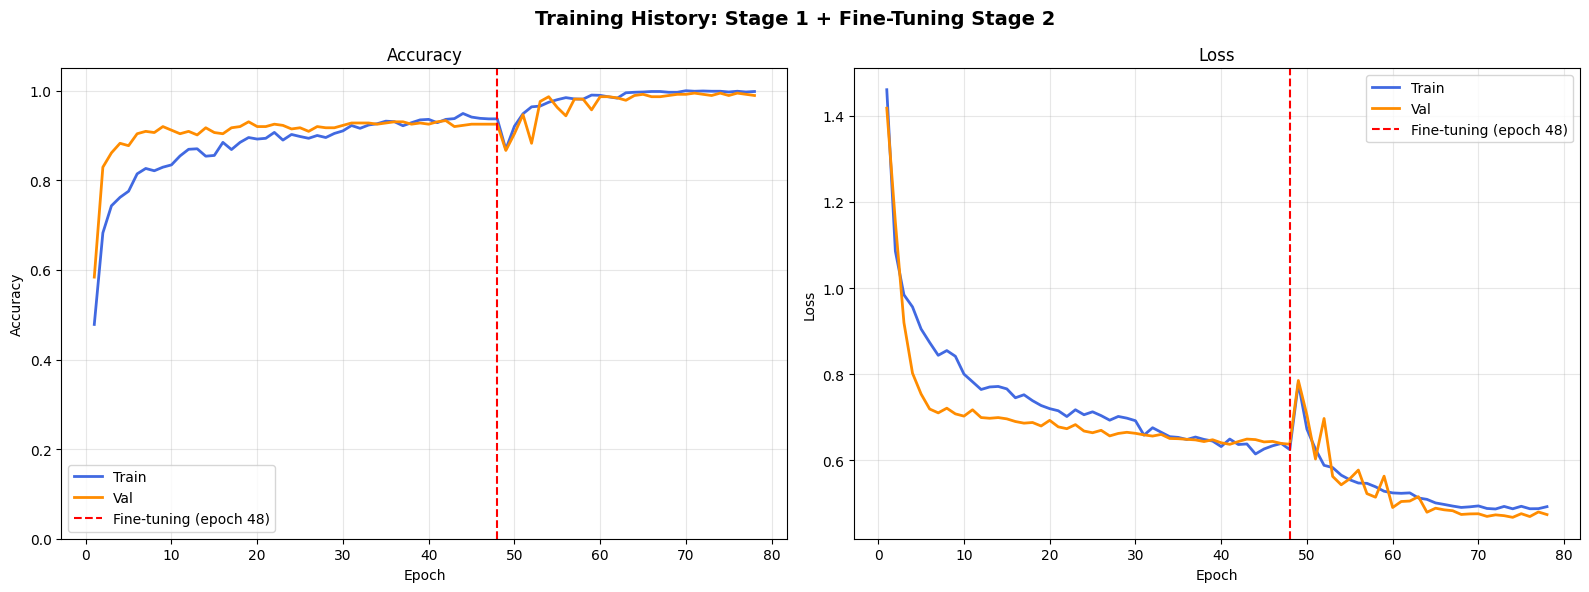

  ✅ Grafik history tersimpan: /content/drive/MyDrive/Cat_Breed/saved_model/training_history.png


In [11]:
# ================================================================
# BAGIAN 10 — VISUALISASI TRAINING HISTORY
# ================================================================

def plot_combined_history(hist1, hist2, save_path: str):
    """
    Menggabungkan history Stage 1 & 2 dalam satu grafik.
    Garis putus-putus merah menandai titik dimulainya fine-tuning.
    """
    acc      = hist1.history['accuracy']     + hist2.history['accuracy']
    val_acc  = hist1.history['val_accuracy'] + hist2.history['val_accuracy']
    loss     = hist1.history['loss']         + hist2.history['loss']
    val_loss = hist1.history['val_loss']     + hist2.history['val_loss']

    ft_start     = len(hist1.history['accuracy'])
    epochs_range = range(1, len(acc) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle("Training History: Stage 1 + Fine-Tuning Stage 2",
                 fontsize=14, fontweight='bold')

    for ax, (train_data, val_data, title, ylabel) in zip(
        axes,
        [
            (acc, val_acc, "Accuracy", "Accuracy"),
            (loss, val_loss, "Loss", "Loss"),
        ]
    ):
        ax.plot(epochs_range, train_data, label='Train', color='royalblue', linewidth=2)
        ax.plot(epochs_range, val_data,   label='Val',   color='darkorange', linewidth=2)
        ax.axvline(x=ft_start, color='red', linestyle='--', linewidth=1.5,
                   label=f'Fine-tuning (epoch {ft_start})')
        ax.set_title(title, fontsize=12)
        ax.set_xlabel("Epoch")
        ax.set_ylabel(ylabel)
        ax.legend()
        ax.grid(True, alpha=0.3)

    axes[0].set_ylim([0, 1.05])

    plt.tight_layout()
    out = os.path.join(save_path, 'training_history.png')
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  ✅ Grafik history tersimpan: {out}")


plot_combined_history(history_stage1, history_stage2, SAVE_PATH)

In [12]:
# ================================================================
# BAGIAN 11 — EVALUASI MODEL
# ================================================================

print("\n" + "=" * 60)
print("  EVALUASI MODEL PADA TEST SET")
print("=" * 60)

test_loss, test_acc = model.evaluate(test_generator, verbose=1)
print(f"\n  Test Loss     : {test_loss:.4f}")
print(f"  Test Accuracy : {test_acc:.4f}  ({test_acc * 100:.2f}%)")

# --- Prediksi ---
print("\n  Menjalankan prediksi...")
preds        = model.predict(test_generator, verbose=1)
pred_classes = np.argmax(preds, axis=1)
true_classes = test_generator.classes
class_names  = list(test_generator.class_indices.keys())

# --- Classification Report ---
print("\n" + "=" * 60)
print("  CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(true_classes, pred_classes, target_names=class_names))


  EVALUASI MODEL PADA TEST SET
24/24 ━━━━━━━━━━━━━━━━━━━━ 271s 12s/step - accuracy: 0.9893 - loss: 0.4796

  Test Loss     : 0.4796
  Test Accuracy : 0.9893  (98.93%)

  Menjalankan prediksi...
24/24 ━━━━━━━━━━━━━━━━━━━━ 8s 286ms/step

  CLASSIFICATION REPORT
               precision    recall  f1-score   support

       Bombay       1.00      1.00      1.00        75
   Maine_Coon       0.97      1.00      0.99        75
Scottish_Fold       1.00      0.96      0.98        75
      Siamese       0.99      0.99      0.99        75
       Sphynx       0.99      1.00      0.99        75

     accuracy                           0.99       375
    macro avg       0.99      0.99      0.99       375
 weighted avg       0.99      0.99      0.99       375



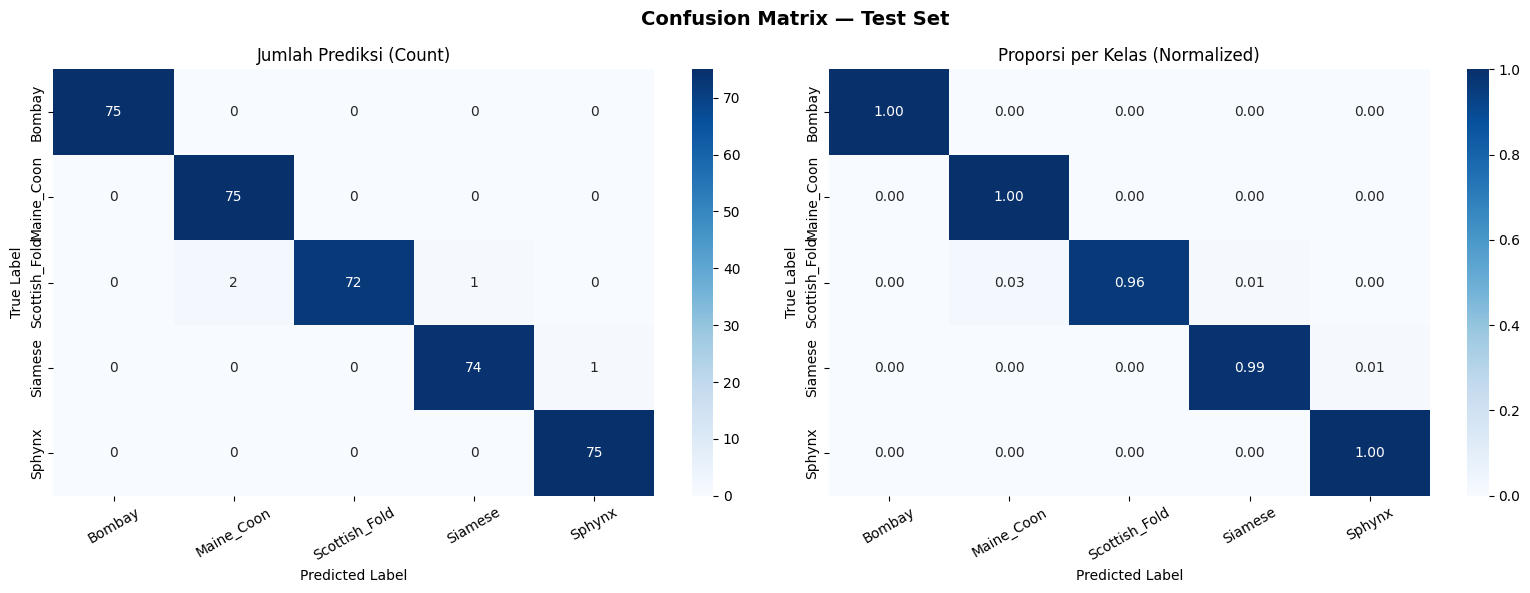

  Confusion matrix tersimpan: /content/drive/MyDrive/Cat_Breed/saved_model/confusion_matrix.png


In [14]:
# ================================================================
# BAGIAN 12 — CONFUSION MATRIX
# ================================================================

def plot_confusion_matrix(true_cls, pred_cls, class_names: list, save_path: str):
    """Menampilkan confusion matrix dalam dua versi: count & normalized."""
    cm            = confusion_matrix(true_cls, pred_cls)
    cm_normalized = cm.astype('float') / cm.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle("Confusion Matrix — Test Set", fontsize=14, fontweight='bold')

    params = [
        (cm,            'd',    "Jumlah Prediksi (Count)"),
        (cm_normalized, '.2f',  "Proporsi per Kelas (Normalized)"),
    ]
    for ax, (data, fmt, title) in zip(axes, params):
        sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                    xticklabels=class_names, yticklabels=class_names, ax=ax)
        ax.set_title(title)
        ax.set_ylabel("True Label")
        ax.set_xlabel("Predicted Label")
        ax.tick_params(axis='x', rotation=30)

    plt.tight_layout()
    out = os.path.join(save_path, 'confusion_matrix.png')
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  Confusion matrix tersimpan: {out}")


plot_confusion_matrix(true_classes, pred_classes, class_names, SAVE_PATH)

  Visualisasi prediksi tersimpan: /content/drive/MyDrive/Cat_Breed/saved_model/sample_predictions.png


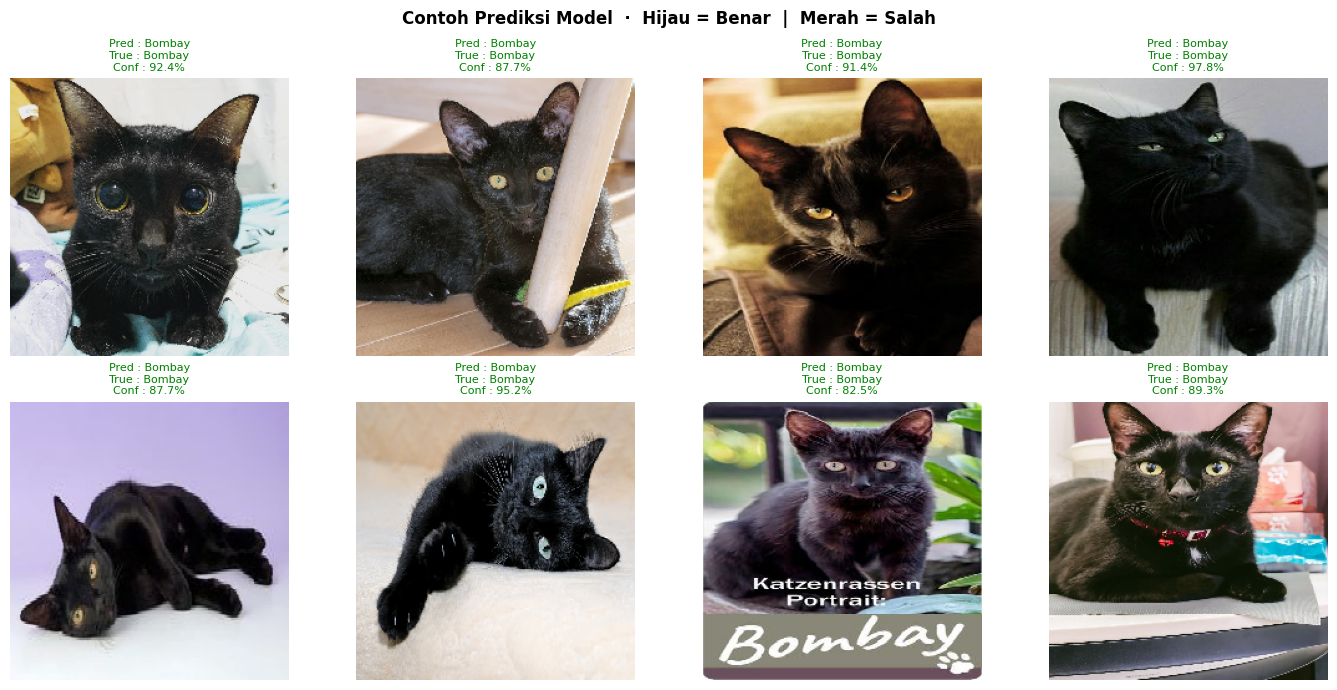

In [15]:
# ================================================================
# BAGIAN 13 — VISUALISASI PREDIKSI (BENAR & SALAH)
# ================================================================

def plot_predictions(generator, model, class_names: list,
                     n: int = 8, save_path: str = ""):
    """
    Menampilkan n sampel prediksi dari test generator.
    Label hijau = benar, merah = salah.
    Border warna memperjelas status prediksi secara visual.
    """
    images, labels = next(generator)
    p           = model.predict(images, verbose=0)
    pred_idx    = np.argmax(p, axis=1)
    true_idx    = np.argmax(labels, axis=1)

    n    = min(n, len(images))
    cols = 4
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(14, rows * 3.5))
    fig.suptitle("Contoh Prediksi Model  ·  Hijau = Benar  |  Merah = Salah",
                 fontsize=12, fontweight='bold')

    for i, ax in enumerate(axes.flat):
        if i < n:
            ax.imshow(images[i])
            color = 'green' if pred_idx[i] == true_idx[i] else 'red'
            ax.set_title(
                f"Pred : {class_names[pred_idx[i]]}\n"
                f"True : {class_names[true_idx[i]]}\n"
                f"Conf : {p[i][pred_idx[i]]:.1%}",
                color=color, fontsize=8
            )
            for spine in ax.spines.values():
                spine.set_edgecolor(color)
                spine.set_linewidth(3)
        ax.axis('off')

    plt.tight_layout()
    if save_path:
        out = os.path.join(save_path, 'sample_predictions.png')
        plt.savefig(out, dpi=150, bbox_inches='tight')
        print(f"  Visualisasi prediksi tersimpan: {out}")
    plt.show()


plot_predictions(test_generator, model, class_names, save_path=SAVE_PATH)

  Grad-CAM tersimpan: /content/drive/MyDrive/Cat_Breed/saved_model/gradcam_visualization.png


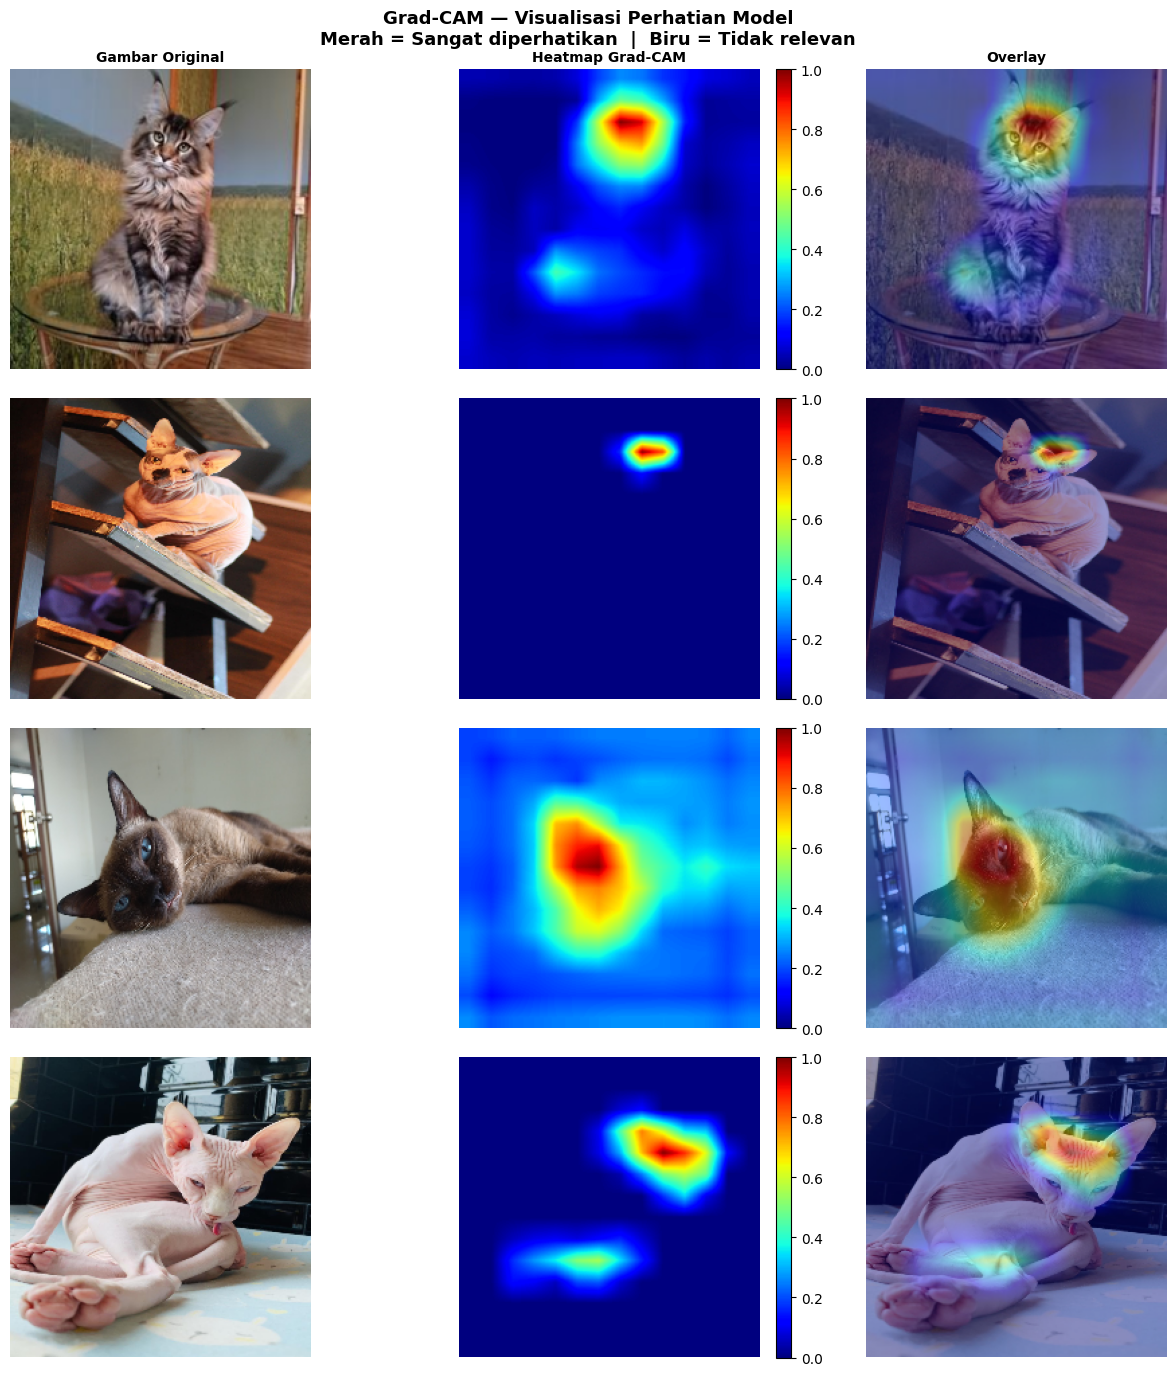

In [16]:
# ================================================================
# BAGIAN 14 — GRAD-CAM
# ================================================================

def make_gradcam_heatmap(img_array: np.ndarray,
                         model,
                         last_conv_layer_name: str) -> tuple:
    """
    Menghasilkan heatmap Grad-CAM dari layer konvolusi target.

    Args:
        img_array           : Array gambar (1, H, W, 3), sudah ternormalisasi
        model               : Model Keras yang sudah dilatih
        last_conv_layer_name: Nama layer konvolusi terakhir

    Returns:
        heatmap     : Array 2D ternormalisasi [0, 1]
        pred_class  : Indeks kelas yang diprediksi
    """
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        pred_class = tf.argmax(predictions[0])
        loss       = predictions[:, pred_class]

    grads        = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    heatmap = conv_outputs[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.nn.relu(heatmap).numpy()

    if heatmap.max() > 0:
        heatmap = heatmap / heatmap.max()

    return heatmap, int(pred_class.numpy())


def overlay_gradcam(img_path: str, heatmap: np.ndarray,
                    target_size: tuple, alpha: float = 0.4) -> tuple:
    """
    Menggabungkan heatmap Grad-CAM dengan gambar asli.

    Returns:
        img_rgb       : Gambar asli (RGB)
        heatmap_2d    : Heatmap yang sudah di-resize
        superimposed  : Overlay gambar + heatmap
    """
    img_bgr  = cv2.resize(cv2.imread(img_path), target_size)
    img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    hm       = cv2.resize(heatmap, target_size)
    hm_color = cv2.applyColorMap(np.uint8(255 * hm), cv2.COLORMAP_JET)
    hm_rgb   = cv2.cvtColor(hm_color, cv2.COLOR_BGR2RGB)

    superimposed = cv2.addWeighted(img_rgb, 1 - alpha, hm_rgb, alpha, 0)
    return img_rgb, hm, superimposed


def visualize_gradcam_batch(generator, model, class_names: list,
                            n_samples: int = 4,
                            last_conv_layer: str = LAST_CONV_LAYER,
                            save_path: str = ""):
    """
    Visualisasi Grad-CAM untuk n_samples gambar dari generator.
    Kolom: Original | Heatmap | Overlay
    """
    filepaths    = generator.filepaths
    true_cls_all = generator.classes
    indices      = np.random.choice(len(filepaths), size=n_samples, replace=False)

    fig, axes = plt.subplots(n_samples, 3, figsize=(13, n_samples * 3.5))
    fig.suptitle(
        "Grad-CAM — Visualisasi Perhatian Model\n"
        "Merah = Sangat diperhatikan  |  Biru = Tidak relevan",
        fontsize=13, fontweight='bold'
    )

    # Header kolom
    for ax, title in zip(axes[0], ["Gambar Original", "Heatmap Grad-CAM", "Overlay"]):
        ax.set_title(title, fontweight='bold', fontsize=10)

    for row, idx in enumerate(indices):
        img_path   = filepaths[idx]
        true_label = class_names[true_cls_all[idx]]

        img       = tf.keras.utils.load_img(img_path, target_size=IMG_SIZE)
        img_array = np.expand_dims(
            tf.keras.utils.img_to_array(img) / 255.0, axis=0
        )

        heatmap, pred_idx         = make_gradcam_heatmap(img_array, model, last_conv_layer)
        pred_label                = class_names[pred_idx]
        img_orig, hm, overlay     = overlay_gradcam(img_path, heatmap, IMG_SIZE)
        color                     = 'green' if true_label == pred_label else 'red'

        axes[row, 0].imshow(img_orig)
        axes[row, 0].set_ylabel(
            f"True : {true_label}\nPred : {pred_label}",
            fontsize=8, color=color
        )
        axes[row, 0].axis('off')

        im = axes[row, 1].imshow(hm, cmap='jet', vmin=0, vmax=1)
        plt.colorbar(im, ax=axes[row, 1], fraction=0.046, pad=0.04)
        axes[row, 1].axis('off')

        axes[row, 2].imshow(overlay)
        axes[row, 2].axis('off')

    plt.tight_layout()
    if save_path:
        out = os.path.join(save_path, 'gradcam_visualization.png')
        plt.savefig(out, dpi=150, bbox_inches='tight')
        print(f"  Grad-CAM tersimpan: {out}")
    plt.show()


visualize_gradcam_batch(test_generator, model, class_names, save_path=SAVE_PATH)

In [17]:
# ================================================================
# BAGIAN 15 — RINGKASAN HASIL AKHIR
# ================================================================

best_val_s1 = max(history_stage1.history['val_accuracy'])
best_val_s2 = max(history_stage2.history['val_accuracy'])
best_val    = max(best_val_s1, best_val_s2)
target_met  = "ERCAPAI" if test_acc >= 0.80 else "BELUM TERCAPAI"

print("\n" + "=" * 60)
print("  RINGKASAN HASIL AKHIR TRAINING")
print("=" * 60)
print(f"  Best Val Accuracy  Stage 1  : {best_val_s1:.4f}  ({best_val_s1*100:.2f}%)")
print(f"  Best Val Accuracy  Stage 2  : {best_val_s2:.4f}  ({best_val_s2*100:.2f}%)")
print(f"  Best Val Accuracy  Overall  : {best_val:.4f}  ({best_val*100:.2f}%)")
print(f"  Test Accuracy               : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"  Test Loss                   : {test_loss:.4f}")
print(f"  Target ≥ 80%                : {target_met}")
print(f"\n  File tersimpan di           : {SAVE_PATH}")
print(f"    ├── best_stage1.h5")
print(f"    ├── best_stage2.h5")
print(f"    ├── vgg16_catbreed_final.h5")
print(f"    ├── training_log_stage1.csv      ← [BARU] Log training per epoch")
print(f"    ├── training_log_stage2.csv      ← [BARU] Log fine-tuning per epoch")
print(f"    ├── training_history.png")
print(f"    ├── confusion_matrix.png")
print(f"    ├── sample_predictions.png")
print(f"    ├── gradcam_visualization.png")
print(f"    └── sample_data.png")
print("=" * 60)


  RINGKASAN HASIL AKHIR TRAINING
  Best Val Accuracy  Stage 1  : 0.9333  (93.33%)
  Best Val Accuracy  Stage 2  : 0.9947  (99.47%)
  Best Val Accuracy  Overall  : 0.9947  (99.47%)
  Test Accuracy               : 0.9893  (98.93%)
  Test Loss                   : 0.4796
  Target ≥ 80%                : ERCAPAI

  File tersimpan di           : /content/drive/MyDrive/Cat_Breed/saved_model
    ├── best_stage1.h5
    ├── best_stage2.h5
    ├── vgg16_catbreed_final.h5
    ├── training_log_stage1.csv      ← [BARU] Log training per epoch
    ├── training_log_stage2.csv      ← [BARU] Log fine-tuning per epoch
    ├── training_history.png
    ├── confusion_matrix.png
    ├── sample_predictions.png
    ├── gradcam_visualization.png
    └── sample_data.png
